In [2]:
import pickle

import numpy as np 
import re 
from pathlib import Path
import pandas as pd
import json
import pickle
import importlib 
import IPython.display as ipd
%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
from scipy import stats 
# from matplotlib.ticker import FormatStrFormatter
from src import util_analysis
import src.util_process_prolific as up 
from tqdm import tqdm
importlib.reload(up)

<module 'src.util_process_prolific' from '/net/vast-storage/scratch/vast/mcdermott/imgriff/projects/torch_2_aud_attn/src/util_process_prolific.py'>

# Experiment 1

In [3]:
## import class maps
import pickle
cv_word_2_class = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
cv_class_2_word = {v:k for k,v in cv_word_2_class.items()}

### Get conditions 
path_to_expmt_stim = Path("/om/user/imgriff/datasets/human_word_rec_SWC_2024/")
manifests = pd.read_pickle(path_to_expmt_stim / "human_cue_target_distractor_df_w_meta_transcripts_w_f0.pdpkl")


cond_map = pickle.load( open(path_to_expmt_stim / "human_attn_expmt_cond_map.pkl", "rb" )) 
conds = set([cond for cond,snr in cond_map.values()])

test_condition_dict = {'music':"background_musdb18hq",
                       "babble":"background_cv08talkerbabble",
                       "stationary": "background_issnstationary",
                       "natural scene": "background_ieeeaaspcasa",
                       "clean": "SILENCE"}

test_cond_to_human = {v:k for k,v in test_condition_dict.items()}
cond_remap = {}
for cond in conds:
    if cond in test_cond_to_human:
        cond_remap[cond] = test_cond_to_human[cond]
    else:
        cond_remap[cond] = cond 
cond_remap['natural scene'] = 'natural scene'


In [4]:
def remap_1_distractor_str(cond_str):
    if 'english' in cond_str:
        return '1-talker'
    if 'mandarin' in cond_str:
        return "Mandarin distractor"
    if 'dutch' in cond_str:
        return "Dutch distractor"

In [5]:

model_names = [ ]

# get names for arch_search models 
arch_search_models = [path.stem for path in Path('swc_2024_eval_full_stim/').glob('*post*')]
model_names.extend(arch_search_models)

model_name_dict = {
                   "word_task_v10_gain_post_norm_config": 'Norm before gain model',
                  }


all_model_results = []
all_model_f0_results = []

str_to_cond = {v:k for k,v in test_condition_dict.items()}

## preselect manifest columns 
cols_to_merge = [
                #  'stim_name',
                 'gender',
                 'word',
                 'word_int',
                 'target_f0',
                 'english_distractor_f0',
                 'mandarin_distractor_f0',
                 'dutch_distractor_f0',
                 'target_transcripts',
                 'same_sex_distractor_1_transcripts',
                 'diff_sex_distractor_1_transcripts',
                 "same_sex_dist_1_word",
                 "diff_sex_dist_1_word"

]

manifests['word_int'] = manifests.word.replace(cv_word_2_class)
model_manifest = manifests[cols_to_merge].sort_values(['gender', 'word']).copy()
model_manifest['df_index'] = model_manifest.index

# update gt manifests to match readable format 
for model_name in model_names:
    print(model_name)
    output_paths = list(Path(f'swc_2024_eval_full_stim/{model_name}').glob('*.csv'))
    print(len(output_paths))
    results_dfs = []

    for path in output_paths:
        # print(path)
        try:
            df = pd.read_csv(path)
            # reformat dict
            df['model'] = path.parent.name
            #parts of name 
            parts = path.stem.split(path.parent.name)[-1].split('_')   
            # if 'stim_tag' in df.columns:
            #     # rename 
            #     df.rename(columns={'stim_tag':'stim_name'}, inplace=True)
            # use re to split path.stem after model name and before <int>dB 
            df['background_condition'] = [v for v in cond_remap.values() if "_".join(v.split(' ')) in path.stem][0]
            if 'clean' in path.stem:
                df['background_condition'] = 'clean'
                df['snr'] =  'inf' # really np.inf, 6 for plotting 
            else:
                df['snr'] = int(re.search('(-?\d+)dB', path.stem).group(0).strip('dB'))

            df['test_index'] = df.index
            df = pd.merge(df,
                model_manifest,
                            left_on=["test_index", "true_word_int"], right_on=["df_index", "word_int"])
            if 'dutch' in df['background_condition'].unique()[0]:
                continue
            results_dfs.append(df)
        except Exception as e:
            # print(e)
            continue

    model_results = pd.concat(results_dfs, axis=0, ignore_index=True)
    if model_name in model_name_dict:
        model_str = model_name_dict[model_name]
    elif "arch_" in model_name:
        model_str = "Feature-gain Model"
    else:
        model_str = model_name

    model_results['group'] = model_str
    ## Load in model vocab 
    model_results['pred_word'] = model_results['pred_word_int'].replace(cv_class_2_word)
    model_results['true_word'] = model_results['true_word_int'].replace(cv_class_2_word)


    # Add 1-talker condition metadata to model results

    # add confusions 
    model_results['confusions'] = (model_results.pred_word == model_results.same_sex_dist_1_word).astype('int')

    # add adjusted accuracy and confusions 
    pred_words = model_results.pred_word.values
    target_words = model_results.word.values
    target_transcripts = model_results.target_transcripts.values
    same_sex_distractor_words = model_results.same_sex_dist_1_word.values
    diff_sex_distractor_words = model_results.same_sex_dist_1_word.values
    same_sex_distractor_transcripts = model_results.same_sex_distractor_1_transcripts.values
    diff_sex_distractor_transcripts = model_results.diff_sex_distractor_1_transcripts.values


    adjusted_acc = np.array([int(pred_word in target_transcript or pred_word == target_word)
                                if not isinstance(target_transcript, float) else np.nan
                                for pred_word, target_word, target_transcript in zip(pred_words, target_words, target_transcripts)
                                ])

    adjusted_confs = np.array([int(pred_word in same_sex_transcript or pred_word in diff_sex_transcript or pred_word == same_sex_word or pred_word == diff_sex_word)
                                if not (isinstance(same_sex_transcript, float) and isinstance(diff_sex_transcript, float)) else np.nan
                                for pred_word, same_sex_word, diff_sex_word, same_sex_transcript, diff_sex_transcript in zip(pred_words, same_sex_distractor_words, diff_sex_distractor_words,  same_sex_distractor_transcripts, diff_sex_distractor_transcripts)
                                ])
    
    model_results['adjusted_accuracy'] = adjusted_acc
    model_results['adjusted_confusions'] = adjusted_confs
    model_results.loc[model_results.background_condition.str.contains('1-talker'), 'sex_cond'] = model_results.loc[model_results.background_condition.str.contains('1-talker'), 'background_condition'].str.split('-').str[-1].str.title()
    model_results.loc[model_results.background_condition.str.contains('1-talker'), 'dist_lang'] = model_results.loc[model_results.background_condition.str.contains('1-talker'), 'background_condition'].str.split('-').str[-2].str.title()
    model_results.loc[model_results.background_condition.str.contains('1-talker'), 'background_condition'] = model_results.loc[model_results.background_condition.str.contains('1-talker'), 'background_condition'].apply(remap_1_distractor_str)

    
    all_model_results.append(model_results)


    model_f0_df = model_results[model_results.background_condition.isin([ "1-talker", 'Mandarin distractor', 'Dutch distractor', 'clean'])].copy()
    model_f0_df.loc[model_f0_df.dist_lang == 'English', 'distractor_f0'] = model_f0_df.loc[model_f0_df.dist_lang == 'English', 'english_distractor_f0'].values
    model_f0_df.loc[model_f0_df.dist_lang == 'Mandarin', 'distractor_f0'] = model_f0_df.loc[model_f0_df.dist_lang == 'Mandarin', 'mandarin_distractor_f0'].values
    model_f0_df.loc[model_f0_df.dist_lang == 'Dutch', 'distractor_f0'] = model_f0_df.loc[model_f0_df.dist_lang == 'Dutch', 'dutch_distractor_f0'].values
    model_f0_df["abs_f0_diff"] = np.abs(model_f0_df.target_f0 - model_f0_df.distractor_f0)
    model_f0_df["percent_f0_diff"] = model_f0_df.distractor_f0 / model_f0_df.target_f0 
    # model_f0_df["f0_ratio"] = model_f0_df.apply(get_f0_ratio, axis=1)
    model_f0_df.loc[:, "abs_f0_diff"] = np.abs(model_f0_df.target_f0 - model_f0_df.distractor_f0)
    model_f0_df.loc[:, "percent_f0_diff"] = model_f0_df.distractor_f0 / model_f0_df.target_f0 
    all_model_f0_results.append(model_f0_df)

all_model_results = pd.concat(all_model_results, axis=0, ignore_index=True)
all_model_f0_results = pd.concat(all_model_f0_results, axis=0, ignore_index=True)

/tmp/ipykernel_422363/543971170.py:35: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  manifests['word_int'] = manifests.word.replace(cv_word_2_class)


word_task_v10_gain_post_norm_config
61


In [6]:
all_model_results.model.value_counts()


model
word_task_v10_gain_post_norm_config    49776
Name: count, dtype: int64

In [7]:
all_model_results.loc[all_model_results.snr == np.inf, 'snr'] = 6
all_model_results.loc[all_model_results.snr == 'inf', 'snr'] = 6
all_model_results.snr = all_model_results.snr.astype('int')

all_model_results['background_condition'].rename({"stationary":"noise"}, inplace=True)
# all_model_results = all_model_results[all_model_results.snr > -12]
all_model_results.loc[all_model_results.background_condition == "stationary", 'background_condition'] = "noise"

In [8]:
#################################
# Setup summary for models  
################################# 
all_model_f0_results_to_analyze = all_model_f0_results.copy()
all_model_f0_results_to_analyze['id_subject'] = all_model_f0_results_to_analyze['group']
all_model_f0_results_to_analyze.loc[all_model_f0_results_to_analyze.snr == 'inf', 'sex_cond'] = 'clean'
all_model_f0_results_to_analyze.loc[all_model_f0_results_to_analyze.snr == 'inf', 'dist_lang'] = 'clean'

model_f0_summary = (all_model_f0_results_to_analyze.groupby(["snr", "model", "sex_cond", "dist_lang"])
                     .agg({
                            'adjusted_accuracy':['mean'],
                            'adjusted_confusions':['mean']})
                     .reset_index())
model_f0_summary['snr'] = model_f0_summary['snr'].replace(np.inf, 6)
model_f0_summary['snr'] =  model_f0_summary['snr'].replace("inf", 6)
model_f0_summary['snr'] = model_f0_summary['snr'].astype('int')
# flatten multiindex 
model_f0_summary.columns = ['_'.join(col).strip() for col in model_f0_summary.columns.values]
# remove trailing underscore
model_f0_summary.columns = [col[:-1] if col.endswith('_') else col for col in model_f0_summary.columns.values]



#########################################
# Summarize sex and lang results models
#########################################
control_model_f0_df = model_f0_summary[~model_f0_summary.model.str.contains('main|arch_')].copy()
control_sex_summary = []
for (model, snr, sex_cond), _ in control_model_f0_df.groupby(['model', 'snr', 'sex_cond']):
       if sex_cond == 'clean':
              continue
       else:
              data = all_model_f0_results_to_analyze[(all_model_f0_results_to_analyze.model == model)
                                                        & (all_model_f0_results_to_analyze.snr == snr)
                                                        & (all_model_f0_results_to_analyze.sex_cond == sex_cond)]
              accs = data.adjusted_accuracy.values
              acc_sem = util_analysis.bootstrap_sem(accs)
              group = data.group.values[0]

              # get confusions
              confs = data[data.dist_lang == 'English'].adjusted_confusions.values     
              conf_sem = util_analysis.bootstrap_sem(confs)

              control_sex_summary.append(
                                   {'group':group, 'model':model, 'snr': snr, "background_condition":sex_cond, 
                                   'accuracy': accs.mean(), 'acc_sem': acc_sem,
                                   'confusions': confs.mean(), 'conf_sem': conf_sem}
                     )

control_sex_summary_df = pd.DataFrame(control_sex_summary)

control_lang_summary = []
for (model, snr, dist_lang), _ in control_model_f0_df.groupby(['model', 'snr','dist_lang']):
       if dist_lang == 'clean':
              continue 

       else:
              data = all_model_f0_results_to_analyze[(all_model_f0_results_to_analyze.model == model)
                                                        & (all_model_f0_results_to_analyze.snr == snr)
                                                        & (all_model_f0_results_to_analyze.dist_lang == dist_lang)]
              accs = data.adjusted_accuracy.values
              confs = data.adjusted_confusions.values
              acc_sem = util_analysis.bootstrap_sem(accs)
              conf_sem = util_analysis.bootstrap_sem(confs)
              group = data.group.values[0]

              control_lang_summary.append(
                                   {'group':group, 'model':model, 'snr': snr, "background_condition":dist_lang,
                                   'accuracy': accs.mean(), 'acc_sem': acc_sem,
                                   'confusions': confs.mean(), 'conf_sem': conf_sem}
                     )

control_lang_summary_df = pd.DataFrame(control_lang_summary)
control_sex_lang_summary = pd.concat([control_sex_summary_df, control_lang_summary_df], axis=0, ignore_index=True).drop_duplicates()


##########################
# set common column names 
##########################
full_df_col_names = ['model', 'snr', 'background_condition', 'accuracy', 'acc_sem', 'confusions', 'conf_sem', 'N']
summary_df_col_names = ['group', 'snr', 'background_condition', 'accuracy', 'acc_sem', 'confusions', 'conf_sem', 'N']

# screen language results - will use what we summarized above
combined_results = all_model_results[~all_model_results.background_condition.str.contains('Mandarin|Dutch')]


#############################
# Get control model summary
#############################
control_list = 'Norm'

control_models = combined_results[combined_results.group.str.contains(control_list)].copy()
control_summary = []
for (model, snr, condition), group in control_models.groupby(['model', 'snr', 'background_condition']):
    accs = group.adjusted_accuracy.values
    confs = group.adjusted_confusions.values
    acc_sem = util_analysis.bootstrap_sem(accs)
    conf_sem = util_analysis.bootstrap_sem(confs)
    group = group.group.values[0]
    control_summary.append(
                            {'group':group, 'model':model, 'snr': snr, 'background_condition': condition, 
                             'accuracy': accs.mean(), 'acc_sem': acc_sem,
                             'confusions': confs.mean(), 'conf_sem': conf_sem, 'N':1}
              )
control_summary = pd.DataFrame(control_summary)
# merge and drop duplicate clean row from distractor language analysis 
exp_1_df = pd.concat([control_summary, control_sex_lang_summary], axis=0, ignore_index=True).drop_duplicates()


/tmp/ipykernel_422363/2225343903.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  model_f0_summary['snr'] =  model_f0_summary['snr'].replace("inf", 6)


In [9]:
exp_1_df.model.value_counts()

model
word_task_v10_gain_post_norm_config    56
Name: count, dtype: int64

In [10]:
exp_1_df['snr'] = exp_1_df['snr'].astype('int')
exp_1_df['model'] = exp_1_df['model'].astype('str')

## Experiment 2

In [11]:
meta_df = pd.read_pickle('/om/user/imgriff/datasets/human_swc_popham_exmpt_2024/source_stim_meta_manifest.pdpkl')
## import class maps
import pickle
## load WSN vocab mapping 
word_and_speaker_encodings = pickle.load( open( "/om2/user/imgriff/projects/Auditory-Attention/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
wsn_word_2_class = word_and_speaker_encodings['word_to_idx']
wsn_class_2_word = word_and_speaker_encodings['word_idx_to_word']
cv_word_2_class = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
cv_class_2_word = {v:k for k,v in cv_word_2_class.items()}

# parent_path = Path('/om2/user/imgriff/projects/torch_2_aud_attn/popham_mono_eval/')
parent_path = Path('/om2/user/imgriff/projects/torch_2_aud_attn/popham_swc_eval_all_stim/')

# model_name = 'word_task_standard_v08'
# model_name = 'word_task_half_co_loc_v07'

meta_df = pd.read_pickle('/om/user/imgriff/datasets/human_word_rec_SWC_2024/human_cue_target_distractor_df_w_meta_transcripts.pdpkl')
meta_df['expt_df_ix'] = meta_df.index
cols_to_merge = [
                 'gender',
                 'word',
                 'target_transcripts',
                 'same_sex_distractor_1_transcripts',
                 'diff_sex_distractor_1_transcripts',
                 "same_sex_dist_1_word",
                 "diff_sex_dist_1_word",
                 "expt_df_ix"
]

results_dirs = list(parent_path.rglob(f"*/*post*.csv"))
print(len(results_dirs))

dfs = []

for result_csv in results_dirs:
    # print(result_csv)
    # if not 'word_task_half_co_loc_v09_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout' in str(result_csv) or not '_arch_' in str(result_csv):
    #     # print('skp')
    #     continue
    try:
        df = pd.read_csv(result_csv)
    except Exception as e:
        print(e)
        print(result_csv)
        continue
    
    # break 
    df['target_harmonicity'] = result_csv.stem.split('_target')[0].split('_')[-1].title()
    df['model'] = result_csv.parent.stem
    dist_harm = result_csv.stem.split('_distractor')[0].split('_')[-1].title()
    if dist_harm == 'None':
        dist_harm = 'No Distractor'
    df['distractor_harmonicity'] = dist_harm
    df['target_word'] = df['true_word_int'].replace(cv_class_2_word)
    df['pred_word'] = df['pred_word_int'].replace(cv_class_2_word)
    df = pd.merge(df,
                 meta_df[cols_to_merge],
                 left_on=['target_word','orig_df_row_ix'], right_on=['word', 'expt_df_ix'], how='left')     
    dfs.append(df)

exp_2_df = pd.concat(dfs, axis=0, ignore_index=True)
exp_2_df['confusions'] = (exp_2_df.pred_word == exp_2_df.same_sex_dist_1_word).astype('int') + (exp_2_df.pred_word == exp_2_df.diff_sex_dist_1_word).astype('int')
exp_2_df['accuracy'] = (exp_2_df.pred_word == exp_2_df.target_word).astype('int')
# add adjusted accuracy and confusions 
pred_words = exp_2_df.pred_word.values
target_words = exp_2_df.word.values
target_transcripts = exp_2_df.target_transcripts.values
same_sex_distractor_words = exp_2_df.same_sex_dist_1_word.values
diff_sex_distractor_words = exp_2_df.diff_sex_dist_1_word.values
same_sex_distractor_transcripts = exp_2_df.same_sex_distractor_1_transcripts.values
diff_sex_distractor_transcripts = exp_2_df.diff_sex_distractor_1_transcripts.values


adjusted_acc = np.array([int(pred_word in target_transcript or pred_word == target_word)
                            if not isinstance(target_transcript, float) else np.nan
                            for pred_word, target_word, target_transcript in zip(pred_words, target_words, target_transcripts)
                            ])

adjusted_confs = np.array([int(pred_word in same_sex_transcript or pred_word in diff_sex_transcript or pred_word == same_sex_word or pred_word == diff_sex_word)
                            if not (isinstance(same_sex_transcript, float) and isinstance(diff_sex_transcript, float)) else np.nan
                            for pred_word, same_sex_word, diff_sex_word, same_sex_transcript, diff_sex_transcript in zip(pred_words, same_sex_distractor_words, diff_sex_distractor_words,  same_sex_distractor_transcripts, diff_sex_distractor_transcripts)
                            ])

exp_2_df['adjusted_accuracy'] = adjusted_acc
exp_2_df['adjusted_confusions'] = adjusted_confs



def bootstrap_sem(data, n_bootstraps=1000):
    bootstrapped_means = np.zeros(n_bootstraps)
    n = len(data)
    for i in range(n_bootstraps):
        bootstrapped_sample = np.random.choice(data, size=n, replace=True)
        bootstrapped_means[i] = bootstrapped_sample.mean()
    return bootstrapped_means.std()


# exp_2_df = (exp_2_df.groupby(['model', "target_harmonicity", 'distractor_harmonicity']).agg({
#                             'adjusted_accuracy':['mean'],
#                             'adjusted_confusions':['mean', 'count']})
#                      .reset_index())
exp_2_df_summary = []
for (model, target_harm, dist_harm), group in exp_2_df.groupby(['model', 'target_harmonicity', 'distractor_harmonicity']):
    accs = group.adjusted_accuracy.values
    confs = group.adjusted_confusions.values
    acc_sem = bootstrap_sem(accs)
    conf_sem = bootstrap_sem(confs)
    if 'early' in model:
        model = 'Early-only'
    elif 'late' in model:
        model = 'Late-only'
    elif 'control' in model:
        model = 'Baseline CNN'
    elif '50Hz' in model:
        model = '50Hz cutoff'
    elif 'backbone' in model:
        model = 'Computed-gain model'
    exp_2_df_summary.append(
                            {'model':model, 'target_harmonicity': target_harm, 'distractor_harmonicity': dist_harm, 
                             'accuracy': accs.mean(), 'accuracy_sem': acc_sem, 'confusions': confs.mean(), 'confusions_sem': conf_sem}
    ) 
exp_2_df = pd.DataFrame(exp_2_df_summary)
exp_2_df['N'] = 1
exp_2_df['group'] = exp_2_df['model']
exp_2_df.head()

exp_2_df['background_condition'] = exp_2_df['target_harmonicity'] + '_target_' + exp_2_df['distractor_harmonicity'] + '_distractor'
exp_2_df.drop(['target_harmonicity', 'distractor_harmonicity'], axis=1, inplace=True)

exp_2_df['snr'] = 0 # add snr column to match diotic_results
popham_conds_to_keep = ['Harmonic_target_Harmonic_distractor',
                        'Harmonic_target_No Distractor_distractor',
                        'Inharmonic_target_Inharmonic_distractor',
                        'Inharmonic_target_No Distractor_distractor',
                        'Whispered_target_No Distractor_distractor',
                        'Whispered_target_Whispered_distractor']

exp_2_df = exp_2_df[exp_2_df['background_condition'].isin(popham_conds_to_keep)].reset_index(drop=True)
exp_2_df['group']= "Norm before gain model"
exp_2_df.rename(columns={'accuracy_sem': 'acc_sem', 'confusions_sem': 'conf_sem'}, inplace=True)


12


## Experiment 6

In [12]:
room_manifest = pd.read_pickle('/om2/user/msaddler/spatial_audio_pipeline/assets/brir/eval/manifest_room.pdpkl')
# for tuple_ in room_manifest.itertuples():
#     print(tuple_)
#     break
room_material_map = {}
for row in room_manifest.itertuples():
    wall1 = row.material_x0[0].split(',')[0]
    wall2 = row.material_y1[0].split(',')[0]
    if wall1 == wall2:
        wall_str = f"{wall1} walls"
    else:
        wall_str = f"{wall1} and {wall2} walls"

    floor = row.material_z0[0].split(',')[0]
    ceiling = row.material_z1[0].split(',')[0]
    name_str = f"{wall_str} \n {floor} floor \n {ceiling} ceiling"

    if row.index_room in [5, 6]:
        name_str = 'Alternate speaker room'
    if row.index_room in [6, 8]:
        name_str += ' \n head rotated'
    else:
        head_rotated = ''
    if 'Anechoic' in name_str:
        name_str = "Anechoic"
    room_material_map[row.index_room] = name_str
# room_material_map = {row.index_room: f"{row.material_x0[0].split(',')[0]} and \n {row.material_y1[0].split(',')[0]} walls \n {row.material_z0[0].split(',')[0]} floor \n {row.material_z1[0].split(',')[0]} ceiling" for row in room_manifest.itertuples()}
# room_material_map[5] = 'standard speaker room'
room_material_map

{0: 'Anechoic',
 1: 'Wood panelling on glass fiber blanket walls \n Carpet on foam rubber padding floor \n Highly absorptive panels ceiling',
 2: 'Brick walls \n Wood parquet on concrete floor \n Plaster ceiling',
 3: 'Fiberglass wall treatment walls \n Linoleum floor \n Acoustic tiles ceiling',
 4: 'Concrete walls \n Linoleum floor \n Acoustic tiles ceiling',
 5: 'Alternate speaker room',
 6: 'Alternate speaker room \n head rotated',
 7: 'Fiberglass wall treatment walls \n Linoleum floor \n Acoustic tiles ceiling',
 8: 'Fiberglass wall treatment walls \n Linoleum floor \n Acoustic tiles ceiling \n head rotated'}

In [13]:

manifest_path = "binaural_test_manifests/human_array_exmpt_sim_v02_only_human_locs_w_noise_min_reverb_mit_room_v02.pkl"
with open(manifest_path, "rb") as f: 
    manifest = pickle.load(f)
manifest_df  = pd.DataFrame(manifest.values())
spkr_room_manifest = pd.read_pickle('/om2/user/imgriff/spatial_audio_pipeline/assets/brir/mit_bldg46room1004_min_reverb/manifest_room.pdpkl')



output_paths = list(Path(f"binaural_eval/simulate_2024_human_threshold_experiment_v02_30_dB_pink_noise_min_verb_mit46_1004").glob("*/*post*.pkl"))
# output_paths = list(Path(f"binaural_eval/simulate_2024_human_threshold_experiment_v02_cue_noise").glob("*/*.pkl"))
stim_manifest_df = pd.read_pickle('/om/user/imgriff/datasets/human_word_rec_SWC_2024/full_cue_target_distractor_df_w_meta.pdpkl')


word_class_map = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
ix_to_word = {v:k for k,v in word_class_map.items()}

remap_azim = lambda azim: 360 - azim if azim > 180 else 0 - azim 

results_dfs = []

gend_map = {True:'same', False:'different'}

for path in output_paths:

    res_dict = pickle.load(open(path, 'rb'))
    to_track = {key:val for key,val in res_dict.items() if key != 'textures'}

    df = pd.DataFrame.from_dict(to_track)
    # break
    df.rename(columns={"results": "accuracy"}, inplace=True)
    df['model'] = util_analysis.get_model_name(path.parent.stem)

    df.loc[df.index.values, ['word', 'distractor_word','sex_cond']] = stim_manifest_df.loc[df.stim_ix_list.values, ['word', 'distractor_word','sex_cond']].values
    df['target_word'] = df['true_word_int'].map(ix_to_word)
    df['pred_word'] = df['preds'].map(ix_to_word)
    df['correct'] = (df['true_word_int'] == df['preds']).astype('int')
    df['str_confusions'] = df[['pred_word', 'distractor_word']].apply(lambda x: 1 if x.pred_word in x.distractor_word else 0, axis=1)
    ## Get SNR level from path
    if 'clean' in path.stem:
        snr = 'clean'
    else:
        snr = int(re.search('(-?\d+)_SNR', path.stem).group(0).strip('_SNR'))
    df['snr'] = snr 
    ## Get texture leve lfrom path 
    if "no_texture" in path.stem:
        texture_level = 'no_texture'
    
    elif 'texture' in path.stem: 
        texture_level = re.search('(-?\d+)dB_bg_texture',path.stem).group(0).split('dB')[0]
    elif 'pink_noise' in path.stem:
        texture_level = re.search('(-?\d+)dB_bg_pink_noise',path.stem).group(0).split('dB')[0]


    df['texture_level'] = texture_level
    df["target_azim"], df["target_elev"] = path.stem.split('target_loc_')[1].split('_distract_loc_')[0].split('_')
    df["distractor_azim"], df["distractor_elev"] = path.stem.split('_distract_loc_')[1].split('_')[:2]
    # # map azim to 0-180
    df['target_azim'] = df['target_azim'].astype(int).apply(remap_azim)
    df['distractor_azim'] = df['distractor_azim'].astype(int).apply(remap_azim)
    df['target_elev'] = df['target_elev'].astype(int)
    df['distractor_elev'] = df['distractor_elev'].astype(int)
    df['room_ix'] = int(re.search('room(-?\d+)', path.stem).group(0).strip('room'))
    df['room_type'] = re.search('SNR_(.*?)_room', path.stem).group(0).split('SNR_')[-1].split("_room")[0]
    df['n_distractors'] = 1 if '1_distractor' in path.stem else 2
    df['test_set'] = 'all_stim' if 'all_stim' in path.stem else 'subset'
    results_dfs.append(df)

results = pd.concat(results_dfs)

print(results.model.value_counts())

results.loc[results.room_type.str.contains('eval'), 'room_str'] = results.loc[results.room_type == 'eval', 'room_ix'].map(room_material_map)

results.loc[results.room_type.str.contains('mitb46'), 'room_str'] = 'Normal speaker array'
results.loc[results.room_type.str.contains('mitb46'), 'room_ix'] = 9 # use n from diff room notebook

results.loc[results.room_type.str.contains('reverb'), 'room_str'] = 'Min. reverb speaker array'
results.loc[results.room_type.str.contains('reverb'), 'room_ix'] = 10 # use n from diff room notebook


grouped_model_results = results.groupby(['model', 'target_azim', 'target_elev', 'distractor_azim', 'test_set',  'texture_level',
                                   'distractor_elev', 'sex_cond', 'snr', 'n_distractors', 'room_str']).agg({'accuracy':['mean', 'sem'],
                                                                                                                     'confusions':['mean', 'sem']}).reset_index()
# flatten multiindex
grouped_model_results.columns = ['_'.join(col).strip() for col in grouped_model_results.columns.values]
# remove trailing underscore
grouped_model_results.columns = [col[:-1] if col[-1] == '_' else col for col in grouped_model_results.columns.values]


grouped_model_results['azim_delta'] = (grouped_model_results['distractor_azim'] - grouped_model_results['target_azim']).abs()
grouped_model_results['elev_delta'] = (grouped_model_results['distractor_elev'] - grouped_model_results['target_elev']).abs()

grouped_model_results['distractor_elev_delta'] = (grouped_model_results['target_elev'] - grouped_model_results['distractor_elev']).abs()
exp_6_df = grouped_model_results[grouped_model_results.snr.isin([6,3, 0, -3, -6, -9,])].copy()

exp_6_df = exp_6_df.groupby(['model', 'snr', 'azim_delta', 'elev_delta']).agg({'accuracy_mean':['mean', 'sem'], "confusions_mean":['mean', 'sem']}).reset_index()
exp_6_df.columns = ['model', 'snr', 'azim_delta', 'elev_delta', 'accuracy', 'accuracy_sem', 'confusions', 'confusions_sem']
exp_6_df.loc[exp_6_df.model.str.contains('post'), 'group'] = 'Norm before gain model'
exp_6_df['background_condition'] = exp_6_df['azim_delta'].astype('str') + ' azim delta ' + exp_6_df['elev_delta'].astype('str') + ' elev delta' 
exp_6_df.rename(columns={'accuracy_sem': 'acc_sem', 'confusions_sem': 'conf_sem'}, inplace=True)



model
word_task_v10_gain_post_norm_config    117120
Name: count, dtype: int64


# Experiment 7

In [14]:
# Path to results 

cols_to_merge = ['stim_name',
                 'word',
                 'sex_cond',
                 'target_transcripts',
                 'distractor_transcripts',
                 'distractor_word',

]

# output_paths = list(Path("binaural_eval/word_task_voice_loc_cue_only_v04").glob("*.pkl")) old path for more locations
import pickle
# match human pilot conditions

output_paths = list(Path(f"binaural_eval/sim_azim_spotlight_v02_min_reverb_room1004_30dB_pink_noise_bg/").glob("*/*post*.pkl"))

word_class_map = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
ix_to_word = {v:k for k,v in word_class_map.items()}

remap_azim = lambda azim: 360 - azim if azim > 180 else 0 - azim 

results_dfs = []

gend_map = {True:'same', False:'diff'}

for path in output_paths:
    try:
        df = pd.DataFrame(pd.read_pickle(path))
    
        df['response'] = df['preds'].replace(ix_to_word)
        df['true_word'] = df['true_word_int'].replace(ix_to_word)
        df.rename(columns={"results": "accuracy"}, inplace=True)

        df['target_azim'] = int(re.search('target_loc_(-?\d+)', path.stem).group(0).strip('target_loc_'))
        df['distractor_azim'] = int(re.search('distract_loc_(-?\d+)', path.stem).group(0).strip('distract_loc_'))
        df['target_azim'] = df['target_azim'].apply(remap_azim)
        df['distractor_azim'] = df['distractor_azim'].apply(remap_azim)
        df['model'] = path.parent.stem
        results_dfs.append(df)
    except Exception as error:
        print(error)
        print(path)
        continue


exp_7_df = pd.concat(results_dfs)
exp_7_df['target_azim'] = exp_7_df['target_azim'].abs()
exp_7_df['distractor_azim'] = exp_7_df['distractor_azim'].abs()
exp_7_df['azim_delta'] = np.abs(exp_7_df['distractor_azim'] - exp_7_df['target_azim'])
exp_7_df = exp_7_df[exp_7_df['azim_delta'].isin([0, 10, 30, 90])]
exp_7_df['group'] = exp_7_df['model']
exp_7_df.rename(columns={'target_azim':'Target azimuth'}, inplace=True)
exp_7_df.dropna(axis=1, inplace=True)
exp_7_df['azim_delta'] = exp_7_df['azim_delta'].astype(int)
exp_7_df['Target azimuth'] = exp_7_df['Target azimuth'].astype(int)


exp_7_df = exp_7_df.groupby(['model','Target azimuth', 'azim_delta']).agg({'accuracy': ['mean', 'sem'], 'confusions':['mean', 'sem']}).reset_index()
exp_7_df.columns = ['model', 'target_azim', 'azim_delta', 'accuracy', 'acc_sem', 'confusions', 'conf_sem']
exp_7_df['background_condition'] = exp_7_df['target_azim'].astype('str') + ' target azim ' + exp_7_df['azim_delta'].astype('str') + ' azim delta'
exp_7_df['snr'] = 0 


In [15]:
print(exp_7_df.model.value_counts())

model
word_task_v10_gain_post_norm_config    8
Name: count, dtype: int64


## Merge experiment results 


In [16]:
norm_then_gain_df = pd.concat([exp_1_df, exp_2_df, exp_6_df, exp_7_df], axis=0, ignore_index=True)
norm_then_gain_df['group'] = "Norm before gain model"
norm_then_gain_df['model'] = "Norm before gain model"
norm_then_gain_df.head()

,group,model,snr,background_condition,accuracy,acc_sem,confusions,conf_sem,N,azim_delta,elev_delta,target_azim
0,Norm before gain model,Norm before gain model,-9,1-talker,0.122439,0.007576,0.273566,0.009723,1.0,NaN,NaN,NaN
1,Norm before gain model,Norm before gain model,-9,2-talker,0.036885,0.006047,0.199795,0.013324,1.0,NaN,NaN,NaN
2,Norm before gain model,Norm before gain model,-9,4-talker,0.023566,0.004983,0.056352,0.007423,1.0,NaN,NaN,NaN
3,Norm before gain model,Norm before gain model,-9,babble,0.038934,0.005959,0.004098,0.002076,1.0,NaN,NaN,NaN
4,Norm before gain model,Norm before gain model,-9,music,0.268443,0.014045,0.001025,0.000962,1.0,NaN,NaN,NaN


In [32]:
results_dir = Path('final_results_to_share')

# diotic SWC 
diotic_results = pd.read_csv(results_dir / "experiment_1_df.csv")
diotic_results['experiment'] = 'Diotic'

# Popham SWC
popham_results = pd.read_pickle(results_dir / "df_for_stats_2024_SWC_popham_conditions_humans_N-90_models_v10_w_control_archs.pdpkl")
popham_results.loc[popham_results.group.str.contains("Human"), 'model'] = popham_results.loc[popham_results.group.str.contains("Human"), 'group']
popham_results['snr'] = 0 # add snr column to match diotic_results
popham_conds_to_keep = ['Harmonic_target_Harmonic_distractor',
                        'Harmonic_target_No Distractor_distractor',
                        'Inharmonic_target_Inharmonic_distractor',
                        'Inharmonic_target_No Distractor_distractor',
                        'Whispered_target_No Distractor_distractor',
                        'Whispered_target_Whispered_distractor']

popham_results = popham_results[popham_results['background_condition'].isin(popham_conds_to_keep)].reset_index(drop=True)
popham_results['experiment'] = 'Harmonicity'

# threshold results 
threshold_results = pd.read_pickle(results_dir / "df_for_stats_and_summary_2024_thresholds_humans_N-33_models_v10_w_control_archs.pdpkl")
threshold_results['background_condition'] = threshold_results['azim_delta'].astype('str') + ' azim delta ' + threshold_results['elev_delta'].astype('str') + ' elev delta' 
threshold_results['experiment'] = 'Threshold'
threshold_results.rename(columns={'accuracy_sem': 'acc_sem', 'confusions_sem': 'conf_sem'}, inplace=True)

# Spotlight results 
spotlight_results = pd.read_pickle(results_dir / "df_for_stats_and_summary_2024_spotlight_humans_N-28_models_v10_w_control_archs.pdpkl")
spotlight_results['snr'] = 0 
spotlight_results['background_condition'] = spotlight_results['target_azim'].astype('str') + ' target azim ' + spotlight_results['azim_delta'].astype('str') + ' azim delta'
spotlight_results['experiment'] = 'Spotlight'
spotlight_results.rename(columns={'accuracy_sem': 'acc_sem', 'confusions_sem': 'conf_sem'}, inplace=True)

combined_results = pd.concat([diotic_results, popham_results, threshold_results, spotlight_results], axis=0)
## update model names for comparison 

combined_results.loc[combined_results['model'].str.contains("early"), 'model'] = 'Early-only'
combined_results.loc[combined_results['model'].str.contains("late"), 'model'] = 'Late-only'
combined_results.loc[combined_results['model'].str.contains("control"), 'model'] = 'Baseline CNN'

combined_results['model'] = combined_results['model'].apply(util_analysis.get_model_name)

In [33]:
combined_results.model.value_counts()


model
Feature-gain alt v1     100
Feature-gain alt v9     100
Feature-gain alt v10    100
Feature-gain alt v12    100
Feature-gain alt v2     100
Feature-gain alt v4     100
Feature-gain alt v6     100
Feature-gain alt v7     100
Feature-gain alt v8     100
Baseline CNN            100
Feature-gain main       100
Early-only              100
Late-only               100
Human (N=195)            56
Human (N=33)             30
Humans (N=28)             8
Humans (N = 90)           6
Name: count, dtype: int64

In [34]:
to_analyze = pd.concat([combined_results, norm_then_gain_df], axis=0, ignore_index=True)

In [35]:
to_analyze

,group,snr,background_condition,accuracy,acc_sem,confusions,conf_sem,N,model,experiment,azim_delta,elev_delta,target_azim
0,Human (N=195),-9,1-talker,0.317094,0.019581,0.315385,0.020614,195.0,Human (N=195),Diotic,NaN,NaN,NaN
1,Human (N=195),-9,2-talker,0.066667,0.009281,0.467949,0.019008,195.0,Human (N=195),Diotic,NaN,NaN,NaN
2,Human (N=195),-9,4-talker,0.037607,0.006724,0.110684,0.011536,195.0,Human (N=195),Diotic,NaN,NaN,NaN
3,Human (N=195),-9,babble,0.035897,0.006551,0.005128,0.002544,195.0,Human (N=195),Diotic,NaN,NaN,NaN
4,Human (N=195),-9,music,0.458974,0.019222,0.005128,0.002544,195.0,Human (N=195),Diotic,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,Norm before gain model,0,0 target azim 90 azim delta,0.419057,0.007898,0.002561,0.000809,NaN,Norm before gain model,NaN,90.0,NaN,0.0
1496,Norm before gain model,0,90 target azim 0 azim delta,0.191598,0.006300,0.055328,0.003659,NaN,Norm before gain model,NaN,0.0,NaN,90.0
1497,Norm before gain model,0,90 target azim 10 azim delta,0.195697,0.006350,0.048924,0.003453,NaN,Norm before gain model,NaN,10.0,NaN,90.0
1498,Norm before gain model,0,90 target azim 30 azim delta,0.181352,0.008723,0.048668,0.004871,NaN,Norm before gain model,NaN,30.0,NaN,90.0


In [36]:
# sign test
# from statsmodels.stats.descriptivestats import sign_test

def sign_test(x, mu0):
    n = len(x)
    n_pos = np.sum(x > mu0)
    n_neg = np.sum(x < mu0)
    effect_m = (n_pos - n_neg) / 2 
    p = stats.binomtest(min(n_pos, n_neg), n, p=0.5).pvalue
    return effect_m, p

pooled_results = to_analyze.melt(id_vars=['snr', 'background_condition', 'model'], value_vars=['accuracy', 'confusions'], var_name='metric', value_name='measure')
pooled_results['condition_str'] = pooled_results['snr'].astype(str) + ' dB ' + pooled_results['background_condition'] + ' ' + pooled_results['metric']

human_results = pooled_results[pooled_results.model.str.contains('Human')]
human_results = human_results.sort_values('condition_str')
model_list = [model for model in pooled_results.model.unique() if 'Human' not in model]

model_sim_records_pooled = []

for ix, model in enumerate(model_list):
    model_results = pooled_results[pooled_results.model == model]
    model_results = model_results.sort_values('condition_str')

    ## Get Pearson's r ^ 2  and RMSE 
    r, p = stats.pearsonr(human_results.measure,  model_results.measure)
    r2 = r ** 2
    rmse = np.sqrt(np.mean((human_results.measure.values - model_results.measure.values)**2))
    # add to dict
    record = {'model': model, 'r2': r2, 'rmse': rmse}
    model_sim_records_pooled.append(record)
model_sim_df_pooled = pd.DataFrame.from_records(model_sim_records_pooled)


In [45]:
model_sim_df_pooled

,model,r2,rmse
0,Feature-gain alt v1,0.956452,0.097702
1,Feature-gain alt v10,0.923123,0.115523
2,Feature-gain alt v12,0.941203,0.108784
3,Feature-gain alt v2,0.960421,0.081236
4,Feature-gain alt v4,0.951037,0.103720
5,Feature-gain alt v6,0.958537,0.092331
6,Feature-gain alt v7,0.955893,0.078094
7,Feature-gain alt v8,0.947803,0.094366
8,Feature-gain alt v9,0.954086,0.094552
9,Feature-gain main,0.964026,0.074064


In [46]:
sign_test_dict = []

fba_model_r_dist = model_sim_df_pooled.loc[model_sim_df_pooled.model.str.contains("main|gain"), "r2"].values
fba_model_rmse_dist = model_sim_df_pooled.loc[model_sim_df_pooled.model.str.contains("main|gain"), "rmse"].values
model_names = [m_name for m_name in model_sim_df_pooled.model.unique() if not 'Feature' in m_name]

for model in model_names:
    mod_r2 = model_sim_df_pooled.loc[model_sim_df_pooled.model == model, "r2"].values
    r2_stats_result = sign_test(fba_model_r_dist, mu0=mod_r2)
    r2_diff_of_mean = fba_model_r_dist.mean() - mod_r2
    print(f"Feature-gain v {model}, Pearson's r^2 sign test stat={r2_stats_result[0]} p={r2_stats_result[1]:.5f}, diff of mean={r2_diff_of_mean[0]:.5f}")
    mod_rmse = model_sim_df_pooled.loc[model_sim_df_pooled.model == model, "rmse"].values
    rmse_stats_result = sign_test(fba_model_rmse_dist, mu0=mod_rmse)
    rmse_diff_of_mean = fba_model_rmse_dist.mean() - mod_rmse
    print(f"Feature-gain v {model}, RMSE sign test stat={rmse_stats_result[0]} p={rmse_stats_result[1]:.5f}, diff of mean={rmse_diff_of_mean[0]:.5f}")
    # print(f"Feature-gain v {model}, RMSE sign test stat={stats_result[0]} p={stats_result[1]:.5f}")
    print("")
    record = {'model': model,
     'r2_diff': r2_diff_of_mean[0],
     'r2_sign_test_stat': r2_stats_result[0],
     'r2_sign_test_p': r2_stats_result[1],
     'r2_diff_of_mean': r2_diff_of_mean[0],
     'rmse_diff': rmse_diff_of_mean[0],
     'rmse_sign_test_stat': rmse_stats_result[0],
     'rmse_sign_test_p': rmse_stats_result[1],
     'rmse_diff_of_mean': rmse_diff_of_mean[0]
    }
    sign_test_dict.append(record)

sign_test_df = pd.DataFrame.from_records(sign_test_dict)

Feature-gain v Early-only, Pearson's r^2 sign test stat=4.5 p=0.01172, diff of mean=0.02852
Feature-gain v Early-only, RMSE sign test stat=-4.5 p=0.01172, diff of mean=-0.03262

Feature-gain v Late-only, Pearson's r^2 sign test stat=5.5 p=0.00098, diff of mean=0.49952
Feature-gain v Late-only, RMSE sign test stat=-5.5 p=0.00098, diff of mean=-0.11792

Feature-gain v Baseline CNN, Pearson's r^2 sign test stat=5.5 p=0.00098, diff of mean=0.08597
Feature-gain v Baseline CNN, RMSE sign test stat=-4.5 p=0.01172, diff of mean=-0.06333

Feature-gain v Norm before gain model, Pearson's r^2 sign test stat=5.0 p=0.00098, diff of mean=0.07003
Feature-gain v Norm before gain model, RMSE sign test stat=-5.0 p=0.00098, diff of mean=-0.07121



In [38]:

### Set up color palette 

# add colors for diotic experimental conditions 
hue_order = ['clean', '1-talker',  '2-talker',  '4-talker', 'babble'] # 'noise',  'music', 'natural scene']
palette={}
palette['clean'] = 'k'

# set speech color gradient 
speech_palette = sns.color_palette("RdPu_r")
speech_order = hue_order[1:][::-1]

for ix, group in enumerate(speech_order):
    palette[group] = speech_palette[ix]

# add colors for noise conditions 
noise_order = ['noise',  'music', 'natural scene']
noise_palette = sns.color_palette("YlOrBr_r", n_colors=6)
noise_order = noise_order[::-1]

for ix, group in enumerate(noise_order):
    palette[group] = noise_palette[ix]

# add same and different sex color palette 
hue_order = ['Different', 'Same']
sex_palette = dict(zip(hue_order, sns.color_palette(palette='colorblind', n_colors=10, as_cmap=False)))
palette['Same'] = sex_palette['Same']
palette['Different'] = 'tab:cyan'
palette['English'] = 'tab:pink'
palette['Mandarin'] = 'seagreen'

# add popham conditions 
for cond in popham_conds_to_keep: 
    if 'No Distractor' in cond:
        palette[cond] = 'k'
    else:
        palette[cond] = 'b'

# add threshold conditions
threshold_conditions = threshold_results.background_condition.unique()
for cond in threshold_conditions:
    if '0 azim delta' in cond:
        # is elevation delta condition 
        palette[cond] = 'tab:blue'
    if 'delta 0 elev delta' in cond:
        palette[cond] = 'tab:orange'
# will make colors for confusions, where popham distractor reports are red 

# add colors for spotlight conditions
spotlight_conditions = spotlight_results.background_condition.unique()
spotlight_cmap = sns.color_palette('tab10', n_colors=8)

for cond in spotlight_conditions:
    if cond.startswith('0 target azim'):
        # is elevation delta condition 
        palette[cond] = spotlight_cmap[7]
    elif cond.startswith('90 target azim'):
        palette[cond] = spotlight_cmap[4]

confusion_palette = {k:v for k, v in palette.items()}
# add popham conditions 
for cond in popham_conds_to_keep: 
    if 'No Distractor' in cond:
        confusion_palette[cond] = 'k'
    else:
        confusion_palette[cond] = 'r'

In [39]:
from tqdm.auto import tqdm, trange


In [40]:

import os
from concurrent.futures import ProcessPoolExecutor, as_completed


np.random.seed(0)
data_for_barplot = to_analyze[~to_analyze.model.str.contains('alt')].copy()
data_for_barplot.loc[data_for_barplot['group'].str.contains("Human"), 'group'] = 'Human'  


melted_for_errbars = pd.melt(data_for_barplot, id_vars=['snr', 'background_condition', 'group'], value_vars=['accuracy', 'confusions'], var_name='metric', value_name='measure').reset_index(drop=True)
melted_for_errbars['condition_string'] = melted_for_errbars['snr'].astype(str) + ' dB ' + melted_for_errbars['background_condition'] + ' ' + melted_for_errbars['metric']


melted_for_errbars = melted_for_errbars.sort_values(['condition_string'])

model_list = [model for model in melted_for_errbars.group.unique() if 'Human' not in model]

unique_conds = melted_for_errbars.condition_string.unique()
n_conditions = melted_for_errbars.condition_string.nunique()

model_agg_sim_records = []

n_boots = 1000

full_human_measure = melted_for_errbars[melted_for_errbars.group == 'Human'].sort_values(['condition_string'])

def bootstrap_stats(model, full_human_measure_df, melted_df, unique_conds, n_conditions, n_boots=1000):
    model_measure = melted_df[melted_df.group == model].sort_values(['condition_string'])
    full_human_measure = full_human_measure_df.sort_values(['condition_string'])

    r, _ = stats.pearsonr(full_human_measure.measure, model_measure.measure)
    r2_full = r ** 2
    rmse_full = np.sqrt(np.mean((full_human_measure.measure.values - model_measure.measure.values) ** 2))

    r_boots = np.zeros(n_boots)
    rmse_boots = np.zeros(n_boots)

    for ix in range(n_boots):
        conditions_to_sample = np.random.choice(unique_conds, size=n_conditions, replace=True)

        human_sample = np.array([
            full_human_measure.loc[full_human_measure.condition_string == cond, "measure"].item()
            for cond in conditions_to_sample
        ])
        model_sample = np.array([
            model_measure.loc[model_measure.condition_string == cond, "measure"].item()
            for cond in conditions_to_sample
        ])

        r_boot, _ = stats.pearsonr(human_sample, model_sample)
        r_boots[ix] = r_boot ** 2
        rmse_boots[ix] = np.sqrt(np.mean((human_sample - model_sample) ** 2))

    r_ci = np.percentile(r_boots, [2.5, 97.5])
    rmse_ci = np.percentile(rmse_boots, [2.5, 97.5])
    
    return {
        'group': model,
        'r2': r2_full,
        'r2_ci': r_ci,
        'rmse': rmse_full,
        'rmse_ci': rmse_ci
    }

# Parallel execution
model_agg_sim_records = []
# # get number of processors
n_processors = os.cpu_count()

with ProcessPoolExecutor(max_workers=n_processors) as executor:
    futures = {
        executor.submit(
            bootstrap_stats, model, full_human_measure, melted_for_errbars, unique_conds, n_conditions, n_boots
        ): model
        for model in model_list
    }

    for future in tqdm(as_completed(futures), total=len(model_list)):
        model_agg_sim_records.append(future.result())

model_agg_sim_df = pd.DataFrame.from_records(model_agg_sim_records)

  0%|          | 0/5 [00:00<?, ?it/s]

In [41]:

np.random.seed(0)

results_to_pool = to_analyze[~to_analyze.model.str.contains('alt')]
pooled_results = results_to_pool.melt(id_vars=['snr', 'background_condition', 'model'], value_vars=['accuracy', 'confusions'], var_name='metric', value_name='measure')
pooled_results['condition_str'] = pooled_results['snr'].astype(str) + ' dB ' + pooled_results['background_condition'] + ' ' + pooled_results['metric']


human_results = pooled_results[pooled_results.model.str.contains('Human')]
human_results = human_results.sort_values('condition_str')

model_list = [model for model in pooled_results.model.unique() if 'Human' not in model and 'Feature-gain main' not in model]


model_sim_records_pooled = []

n_boots = 10_000

## Get null dist 
def get_model_human_corr(human_results, model_results):
    ## Get Pearson's r ^ 2  and RMSE 
    r, p = stats.pearsonr(human_results.measure,  model_results.measure)
    r2 = r ** 2
    rmse = np.sqrt(np.mean((human_results.measure.values - model_results.measure.values)**2))
    return r2, rmse
    
def get_bootstrap_iter_result(model_str, results_df, human_results):
    # get data for comparison 
    model_results = results_df[results_df.model.isin([model_str, 'Feature-gain main'])].copy()
    model_names = model_results.model.values
    model_results['model'] = np.random.permutation(model_names) 
    model_a_data = model_results[model_results.model == model_str].sort_values('condition_str')
    model_b_data = model_results[model_results.model == 'Feature-gain main'].sort_values('condition_str')

    # get measures 
    model_a_r2, model_a_rmse = get_model_human_corr(human_results, model_a_data)
    model_b_r2, model_b_rmse = get_model_human_corr(human_results, model_b_data)

    # return diff of measures 
    diff_r2 = model_a_r2 - model_b_r2
    diff_rmse = model_a_rmse - model_b_rmse
    return diff_r2, diff_rmse


model_sim_diff_records = []
fba_result = pooled_results[pooled_results.model == 'Feature-gain main'].copy().sort_values('condition_str')

for model in tqdm(model_list):
    # get actual difference 
    model_result = pooled_results[pooled_results.model == model].copy().sort_values('condition_str')
    # get measures 
    fba_r2, fba_rmse = get_model_human_corr(human_results, fba_result)
    model_r2, model_rmse = get_model_human_corr(human_results, model_result)

    # return diff of measures 
    diff_r2 = fba_r2 - model_r2
    diff_rmse = fba_rmse - model_rmse

    r2_diff_dist = np.zeros(n_boots)
    rmse_diff_dist = np.zeros(n_boots)
    for ix in trange(n_boots, leave=False):
        r2_diff_dist[ix], rmse_diff_dist[ix] = get_bootstrap_iter_result(model, pooled_results, human_results)
    
    # get pvalue 
    p_r2 = (np.abs(r2_diff_dist) > np.abs(diff_r2)).mean()
    p_rmse = (np.abs(rmse_diff_dist) > np.abs(diff_rmse)).mean()
    model_sim_diff_records.append({
            'comparison': f'fba vs {model}',
            'true_r2_diff': diff_r2,
            'r2_pval': p_r2,
            'true_rmse_diff': diff_rmse,
            'rmse_pval': p_rmse,
    })

model_stim_agg_stats = pd.DataFrame.from_records(model_sim_diff_records)

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

In [42]:

from copy import deepcopy
to_plot = model_agg_sim_df.copy()

model_order = deepcopy(util_analysis.model_name_order)

to_plot.sort_values('group', key=lambda x: x.map({model: i for i, model in enumerate(model_order)}), inplace=True)

model_order[0] = "Feature-gain\nModel"
to_plot['group'].replace("Feature-gain Model", "Feature-gain\nModel", inplace=True)

x_vals = {model:ix for ix, model in enumerate(model_order)}
to_plot

/tmp/ipykernel_422363/3953181139.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  to_plot['group'].replace("Feature-gain Model", "Feature-gain\nModel", inplace=True)


,group,r2,r2_ci,rmse,rmse_ci
3,Feature-gain\nModel,0.964026,"[0.9543869241764618, 0.9728190994338544]",0.074064,"[0.06586728613138346, 0.0820400980770086]"
1,Baseline CNN,0.858287,"[0.8315760797753193, 0.8844234451949322]",0.164488,"[0.1489822004716401, 0.17969000433487273]"
4,Early-only,0.915736,"[0.8995505544848419, 0.9329683378328681]",0.133775,"[0.12117182407337851, 0.14624454400062156]"
2,Late-only,0.444736,"[0.3431870832861372, 0.5404317194118744]",0.219079,"[0.20273902738095168, 0.23703422226228216]"
0,Norm before gain model,0.874220,"[0.8349834761149361, 0.9123080844651351]",0.172370,"[0.15392206852084472, 0.19054198124387034]"


In [29]:
model_order

['Feature-gain\nModel', 'Baseline CNN', 'Early-only', 'Late-only']

In [44]:
sign_test_df

,model,r2_diff,r2_sign_test_stat,r2_sign_test_p,r2_diff_of_mean,rmse_diff,rmse_sign_test_stat,rmse_sign_test_p,rmse_diff_of_mean
0,Norm before gain model,0.070034,5.0,0.000977,0.070034,-0.071212,-5.0,0.000977,-0.071212


/tmp/ipykernel_422363/828201540.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  to_plot['group'].replace("Feature-gain Model", "Feature-gain\nModel", inplace=True)


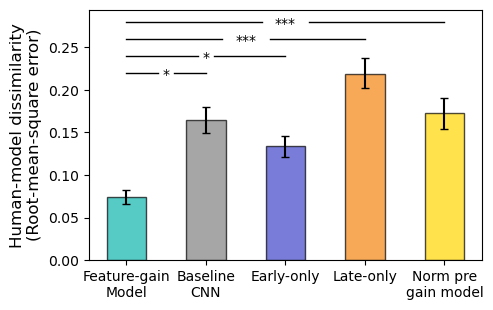

In [60]:
to_plot = model_agg_sim_df.copy()
## add bar plot 
aspect = 3.25
fontsize = 10

fig, ax = plt.subplots(figsize=(5.078125, aspect))


model_order = deepcopy(util_analysis.model_name_order) + ['Norm before gain model']
model_colors = deepcopy(util_analysis.model_color_dict)

to_plot.sort_values('group', key=lambda x: x.map({model: i for i, model in enumerate(model_order)}), inplace=True)
model_order[0] = "Feature-gain\nModel"
to_plot['group'].replace("Feature-gain Model", "Feature-gain\nModel", inplace=True)

xtick_labels = model_order.copy() 
xtick_labels[0] = "Feature-gain\nModel"
xtick_labels[1] = "Baseline\nCNN"
xtick_labels[-1] = "Norm pre\ngain model"
model_colors["Feature-gain\nModel"] = model_colors["Feature-gain Model"]
model_colors["Norm before gain model"] = "gold"
# sort to_plot based on group, according to model order
x_vals = {model:ix for ix, model in enumerate(model_order)}

bar_width = 0.5

for ix, (_, row) in enumerate(to_plot.iterrows()):
    model = row['group']
    if model not in model_order:
        continue 
    y_err = np.array([row['rmse'] - row['rmse_ci'][0], row['rmse_ci'][1] - row['rmse']])
    y_err = y_err.reshape(2,-1)
    ax.bar(x_vals[model], row['rmse'], yerr=y_err, alpha=0.7, color=model_colors[row['group']], width=bar_width, edgecolor='k', capsize=3)
    # get pval 
    if model != 'Feature-gain\nModel':
        p_val = sign_test_df[sign_test_df.model == model].rmse_sign_test_p.item()
        star = util_analysis.get_star(p_val)
        # annot_stat(star, 0, x_vals[model], 0.95 + ix *.06, 0, ax=ax, lw=1)
        util_analysis.draw_stats_bar(ax, 0, x_vals[model], 0.2 + ix *.02, .00, star, col='k', lw=1, fontsize=fontsize, text_gap=0.1)

# ax.set_ylim(0,1.2)
# ax.set_yticks(np.linspace(0,1,5))
# sns.despine()
ax.set_ylabel("Human-model dissimilarity\n(Root-mean-square error)", fontsize=fontsize+2)
ax.set_xticks(np.arange(len(model_order)))
ax.set_xticklabels(xtick_labels, fontsize=fontsize);


In [59]:
sign_test_df

,model,r2_diff,r2_sign_test_stat,r2_sign_test_p,r2_diff_of_mean,rmse_diff,rmse_sign_test_stat,rmse_sign_test_p,rmse_diff_of_mean
0,Early-only,0.028519,4.5,0.011719,0.028519,-0.032617,-4.5,0.011719,-0.032617
1,Late-only,0.499519,5.5,0.000977,0.499519,-0.117921,-5.5,0.000977,-0.117921
2,Baseline CNN,0.085968,5.5,0.000977,0.085968,-0.063330,-4.5,0.011719,-0.063330
3,Norm before gain model,0.070034,5.0,0.000977,0.070034,-0.071212,-5.0,0.000977,-0.071212
